# Poster eval (stylized facts + diversity + micro + macro conditioning)

Poster scenarios: 3 × 2 models (`data/generated_poster/`).
Micro + macro grids: 50 × 2 models (`data/generated_gen1_older/`).
Plot logic from commits `a07c533` / `e89c02c` / `6248a83`; labels match current eval notebooks.


In [26]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import gaussian_kde, norm

sys.path.insert(0, str(Path('..').resolve().parent))
from config import project_config
from evaluate import *

Path('../../figures').mkdir(parents=True, exist_ok=True)


ImportError: numpy._core.multiarray failed to import

In [2]:
# Plot configs (labels match current eval notebooks)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_GEN_CA = '#A8ECFF'
C_GEN_CAFILM = '#38CFEA'
C_REAL = 'tab:blue'
C_NORMAL = 'tab:red'

MODEL_LABELS = {
    'ca': 'Cross-Attn only',
    'ca-film': 'Cross-Attn + FiLM',
}
MODEL_ORDER = ['ca', 'ca-film']

COND_LABELS = {
    'bear': 'Bear',
    'bull': 'Bull',
    'vol': 'Volatility',
}

print('Plot config defined.')


Plot config defined.


In [3]:
"""
Load poster generated data (6 JSONs) and real returns (no global_std rescale).
"""

MODEL_DIRS = {
    'ca': Path('../../data/generated_poster/ca'),
    'ca-film': Path('../../data/generated_poster/ca-film'),
}
CONDITION_FILES = [
    ('bear', 't-10r50i5v20.json'),
    ('bull', 't10r50i5v20.json'),
    ('vol', 't0r70i5v20.json'),
]

gen_data = {}
for model, base_dir in MODEL_DIRS.items():
    gen_data[model] = {}
    for cond_key, filename in CONDITION_FILES:
        with open(base_dir / filename) as f:
            payload = json.load(f)
        gen_data[model][cond_key] = {
            'samples': np.array(payload['samples'], dtype=np.float64),
            'conditions': payload['conditions'],
        }

gen_keys = [(model, cond_key) for model in MODEL_ORDER for cond_key, _ in CONDITION_FILES]
cond_keys = [cond_key for cond_key, _ in CONDITION_FILES]

def box_tick_label(model, cond_key):
    return f"{MODEL_LABELS[model]}\n{COND_LABELS[cond_key]}"

PREP_DIR = Path('../../data/preprocessed')
real_windows = []
for fpath in sorted(PREP_DIR.glob('prep_data_*.json')):
    with open(fpath) as f:
        records = json.load(f)
        for rec in records:
            real_windows.append(rec['returns'])
real_np = np.array(real_windows, dtype=np.float64)

n_gen_paths = {m: sum(gen_data[m][ck]['samples'].shape[0] for ck in cond_keys) for m in MODEL_ORDER}

for model, cond_key in gen_keys:
    arr = gen_data[model][cond_key]['samples']
    print(f"Generated [{MODEL_LABELS[model]} | {COND_LABELS[cond_key]}]: {arr.shape[0]} sequences x {arr.shape[1]} steps")
print(f"Real: {real_np.shape[0]} sequences x {real_np.shape[1]} steps")


Generated [Cross-Attn only | Bear]: 5000 sequences x 64 steps
Generated [Cross-Attn only | Bull]: 5000 sequences x 64 steps
Generated [Cross-Attn only | Volatility]: 5000 sequences x 64 steps
Generated [Cross-Attn + FiLM | Bear]: 5000 sequences x 64 steps
Generated [Cross-Attn + FiLM | Bull]: 5000 sequences x 64 steps
Generated [Cross-Attn + FiLM | Volatility]: 5000 sequences x 64 steps
Real: 7079 sequences x 64 steps


## Stylized facts


In [4]:
"""
1.1 - Fisher's excess kurtosis.
"""
flat_gen = {}
kurt_gen = {}
for model, cond_key in gen_keys:
    arr = gen_data[model][cond_key]['samples']
    flat_gen[(model, cond_key)] = arr.ravel()
    kurt_gen[(model, cond_key)] = fisher_kurtosis(arr)

flat_real = real_np.ravel()
kurt_real = fisher_kurtosis(real_np)

print(f"{'Dataset':<32s}  {'Mean':>10s}  {'Std':>10s}  {'Median':>10s}")
print('-' * 68)
for model, cond_key in gen_keys:
    label = f"{MODEL_LABELS[model]} {COND_LABELS[cond_key]}"
    k = kurt_gen[(model, cond_key)]
    print(f"{label:<32s}  {k.mean():>10f}  {k.std():>10f}  {np.median(k):>10f}")
for label, k in [('Real', kurt_real), ('Normal ref', np.array([0.0]))]:
    print(f"{label:<32s}  {k.mean():>10f}  {k.std():>10f}  {np.median(k):>10f}")


Dataset                                 Mean         Std      Median
--------------------------------------------------------------------
Cross-Attn only Bear                0.878277    1.996574    0.373195
Cross-Attn only Bull                0.875385    1.930201    0.375091
Cross-Attn only Volatility          0.858335    1.947311    0.345055
Cross-Attn + FiLM Bear              0.404355    0.990985    0.176585
Cross-Attn + FiLM Bull              0.381333    0.976371    0.161640
Cross-Attn + FiLM Volatility        0.398034    0.996154    0.185373
Real                                2.477883    4.738218    0.982685
Normal ref                          0.000000    0.000000    0.000000


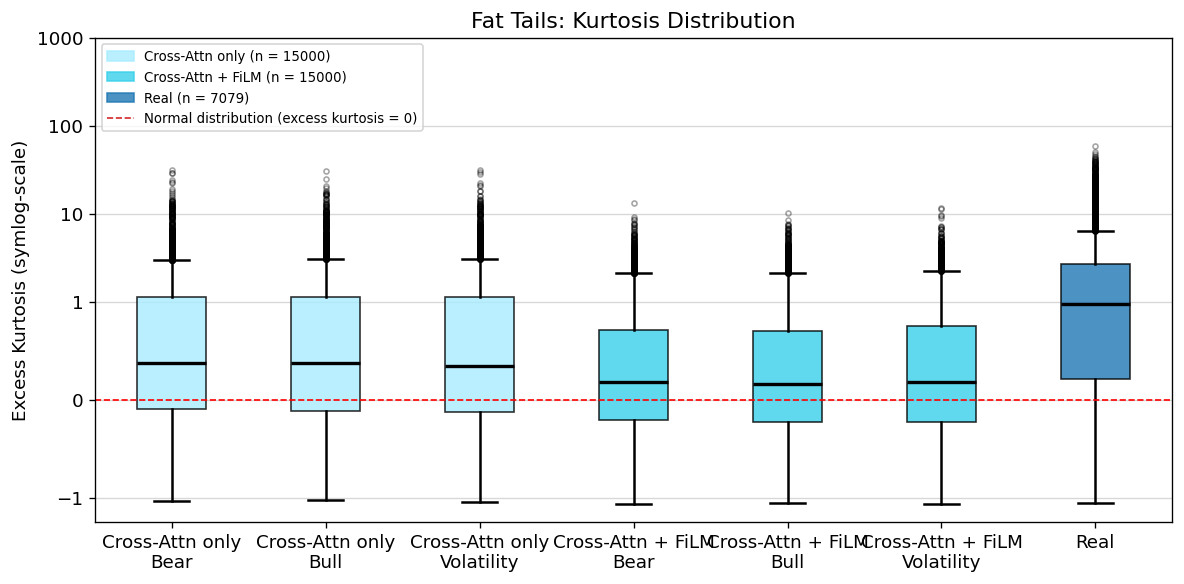

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

kurt_series = [kurt_gen[(model, cond_key)] for model, cond_key in gen_keys] + [kurt_real]
tick_labels = [box_tick_label(model, cond_key) for model, cond_key in gen_keys] + ['Real']

bp = ax.boxplot(
    kurt_series,
    tick_labels=tick_labels,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)

for i, (model, _cond_key) in enumerate(gen_keys):
    color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
    bp['boxes'][i].set_facecolor(color)
    bp['boxes'][i].set_alpha(0.8)

bp['boxes'][-1].set_facecolor(C_REAL)
bp['boxes'][-1].set_alpha(0.8)

ax.set_title('Fat Tails: Kurtosis Distribution')
ax.set_ylabel('Excess Kurtosis (symlog-scale)')
ax.set_yscale('symlog', linthresh=1)
ax.set_ylim(ax.get_ylim()[0], 1000)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)
ax.axhline(0, color='red', linestyle='--', linewidth=1.0, label='Normal distribution (excess kurtosis = 0)')

gen_ca_handle = mpatches.Patch(
    color=C_GEN_CA, alpha=0.8,
    label=f"{MODEL_LABELS['ca']} (n = {n_gen_paths['ca']})",
)
gen_cafilm_handle = mpatches.Patch(
    color=C_GEN_CAFILM, alpha=0.8,
    label=f"{MODEL_LABELS['ca-film']} (n = {n_gen_paths['ca-film']})",
)
real_handle = mpatches.Patch(color=C_REAL, alpha=0.8, label=f'Real (n = {real_np.shape[0]})')
baseline_handle = Line2D(
    [0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0,
    label='Normal distribution (excess kurtosis = 0)',
)
ax.legend(handles=[gen_ca_handle, gen_cafilm_handle, real_handle, baseline_handle], loc='upper left', fontsize=8)

ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('../../figures/kurtosis_boxplot.png')
plt.show()


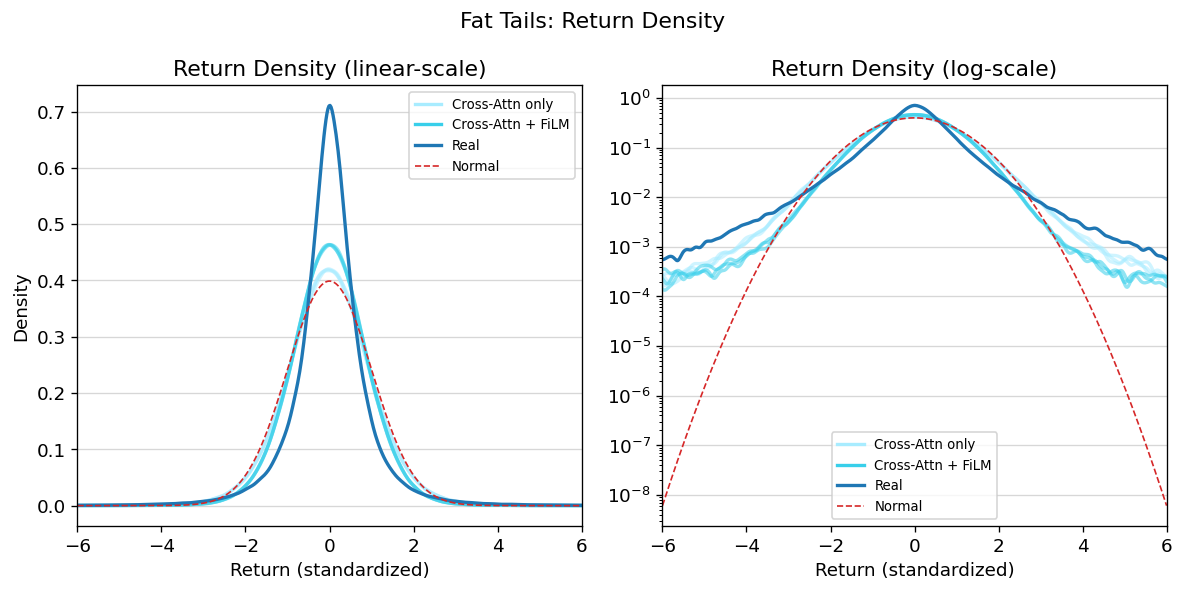

In [6]:
"""
1.3 - KDE overlay.
"""
x_grid = np.linspace(-6, 6, 500)

kde_gen = {
    (model, cond_key): gaussian_kde(flat_gen[(model, cond_key)], bw_method='scott')(x_grid)
    for model, cond_key in gen_keys
}
kde_real = gaussian_kde(flat_real, bw_method='scott')(x_grid)
pdf_norm = norm.pdf(x_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)
for ax, yscale in zip(axes, ['linear', 'log']):
    for model, cond_key in gen_keys:
        color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
        ax.plot(x_grid, kde_gen[(model, cond_key)], color=color, lw=2, alpha=0.55)
    ax.plot(x_grid, kde_real, color=C_REAL, lw=2)
    ax.plot(x_grid, pdf_norm, color=C_NORMAL, linestyle='--', linewidth=1.0)

    generated_ca_handle = Line2D([0], [0], color=C_GEN_CA, lw=2, label=MODEL_LABELS['ca'])
    generated_cafilm_handle = Line2D([0], [0], color=C_GEN_CAFILM, lw=2, label=MODEL_LABELS['ca-film'])
    real_handle = Line2D([0], [0], color=C_REAL, lw=2, label='Real')
    normal_handle = Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Normal')

    ax.set_xlim(-6, 6)
    ax.set_xlabel('Return (standardized)')
    ax.set_yscale(yscale)
    ax.set_title(f'Return Density ({yscale}-scale)')
    ax.legend(handles=[generated_ca_handle, generated_cafilm_handle, real_handle, normal_handle], fontsize=8)
    ax.grid(axis='y', alpha=0.5)

axes[0].set_ylabel('Density')
fig.suptitle('Fat Tails: Return Density')

plt.tight_layout()
plt.savefig('../../figures/kde_overlay.png')
plt.show()


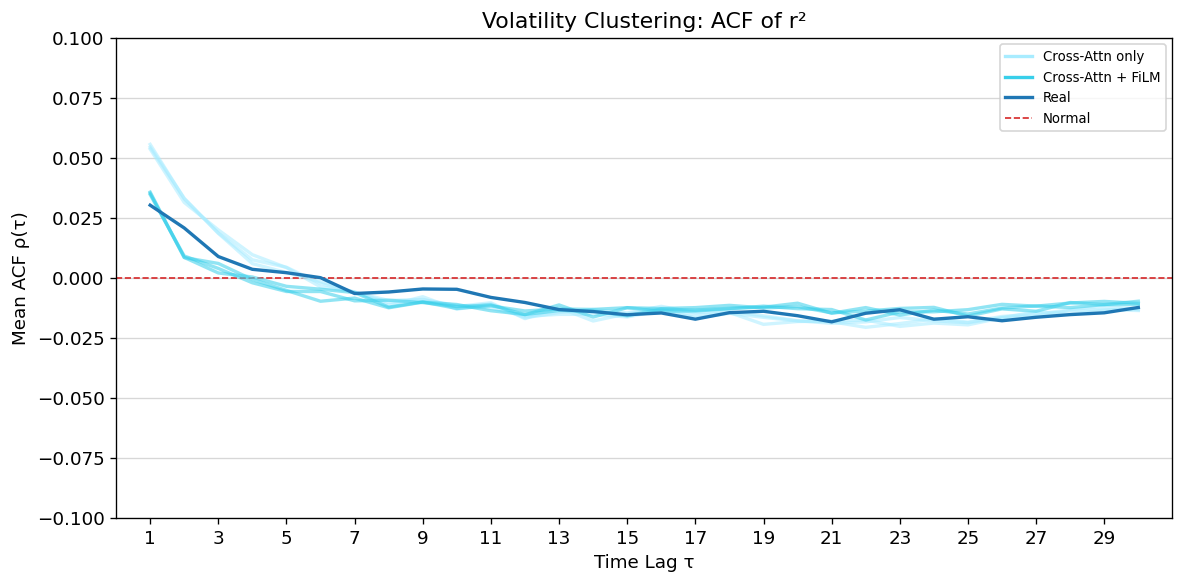

In [7]:
"""
2.2 - ACF plot.
"""
ALL_LAGS = np.arange(1, 31)

acf_gen_full = {
    (model, cond_key): acf_squared(gen_data[model][cond_key]['samples'], ALL_LAGS)
    for model, cond_key in gen_keys
}
acf_real_full = acf_squared(real_np, ALL_LAGS)

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color=C_NORMAL, linestyle='--', linewidth=1.0)
for model, cond_key in gen_keys:
    color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
    ax.plot(ALL_LAGS, acf_gen_full[(model, cond_key)], color=color, lw=2, alpha=0.55)
ax.plot(ALL_LAGS, acf_real_full, color=C_REAL, lw=2)

generated_ca_handle = Line2D([0], [0], color=C_GEN_CA, lw=2, label=MODEL_LABELS['ca'])
generated_cafilm_handle = Line2D([0], [0], color=C_GEN_CAFILM, lw=2, label=MODEL_LABELS['ca-film'])
real_handle = Line2D([0], [0], color=C_REAL, lw=2, label='Real')
normal_handle = Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Normal')

ax.set_xlabel('Time Lag τ')
ax.set_ylabel('Mean ACF ρ(τ)')
ax.set_title('Volatility Clustering: ACF of r²')
ax.set_xlim(0, 31)
ax.set_xticks(np.arange(1, 31, 2))
ax.set_ylim(-0.1, 0.1)
ax.legend(handles=[generated_ca_handle, generated_cafilm_handle, real_handle, normal_handle], fontsize=8)
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('../../figures/acf_curve.png')
plt.show()


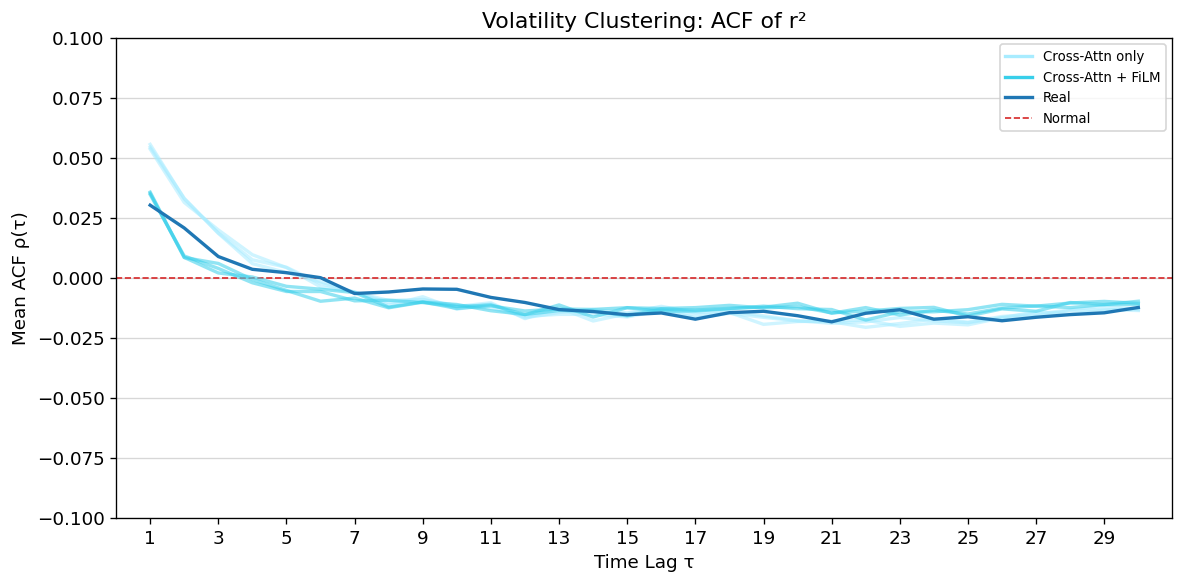

In [8]:
"""
2.2 - ACF plot.
"""
ALL_LAGS = np.arange(1, 31)

acf_gen_full = {
    (model, cond_key): acf_squared(gen_data[model][cond_key]['samples'], ALL_LAGS)
    for model, cond_key in gen_keys
}
acf_real_full = acf_squared(real_np, ALL_LAGS)

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color=C_NORMAL, linestyle='--', linewidth=1.0)
for model, cond_key in gen_keys:
    color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
    ax.plot(ALL_LAGS, acf_gen_full[(model, cond_key)], color=color, lw=2, alpha=0.55)
ax.plot(ALL_LAGS, acf_real_full, color=C_REAL, lw=2)

generated_ca_handle = Line2D([0], [0], color=C_GEN_CA, lw=2, label=MODEL_LABELS['ca'])
generated_cafilm_handle = Line2D([0], [0], color=C_GEN_CAFILM, lw=2, label=MODEL_LABELS['ca-film'])
real_handle = Line2D([0], [0], color=C_REAL, lw=2, label='Real')
normal_handle = Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Normal')

ax.set_xlabel('Time Lag τ')
ax.set_ylabel('Mean ACF ρ(τ)')
ax.set_title('Volatility Clustering: ACF of r²')
ax.set_xlim(0, 31)
ax.set_xticks(np.arange(1, 31, 2))
ax.set_ylim(-0.1, 0.1)
ax.legend(handles=[generated_ca_handle, generated_cafilm_handle, real_handle, normal_handle], fontsize=8)
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('../../figures/acf_curve.png')
plt.show()


## Diversity


In [9]:
"""
2.1 - Euclidean diversity.
"""
SEED = project_config.SEED
MAX_PAIRS = 100000
rng = np.random.default_rng(SEED)

euc_gen = {}
for model, cond_key in gen_keys:
    arr = gen_data[model][cond_key]['samples']
    idx_i, idx_j = sample_pair_indices(arr.shape[0], MAX_PAIRS, rng)
    euc_gen[(model, cond_key)] = euclidean_on_pairs(arr, idx_i, idx_j)

idx_i_real, idx_j_real = sample_pair_indices(real_np.shape[0], MAX_PAIRS, rng)
euc_real = euclidean_on_pairs(real_np, idx_i_real, idx_j_real)

print(f"{'Model':<24} {'Condition':>12} {'min':>10} {'q1':>10} {'median':>10} {'q3':>10} {'max':>10}")
print('-' * 90)
for model, cond_key in gen_keys:
    vals = euc_gen[(model, cond_key)]
    print(
        f"{MODEL_LABELS[model]:<24} "
        f"{COND_LABELS[cond_key]:>12} "
        f"{np.min(vals):>10.2f} {np.percentile(vals, 25):>10.2f} "
        f"{np.median(vals):>10.2f} {np.percentile(vals, 75):>10.2f} {np.max(vals):>10.2f}"
    )
print(
    f"{'Real':<37} "
    f"{np.min(euc_real):>10.2f} {np.percentile(euc_real, 25):>10.2f} "
    f"{np.median(euc_real):>10.2f} {np.percentile(euc_real, 75):>10.2f} {np.max(euc_real):>10.2f}"
)


Model                       Condition        min         q1     median         q3        max
------------------------------------------------------------------------------------------
Cross-Attn only                  Bear       5.34      10.80      11.36      11.93     128.28
Cross-Attn only                  Bull       4.56      10.80      11.37      11.93     109.30
Cross-Attn only            Volatility       5.06      10.81      11.38      11.94     122.27
Cross-Attn + FiLM                Bear       5.88       9.32       9.91      10.50     120.96
Cross-Attn + FiLM                Bull       5.62       9.34       9.92      10.51     102.83
Cross-Attn + FiLM          Volatility       6.03       9.32       9.92      10.52     161.17
Real                                        2.02       6.91       8.92      11.80      55.49


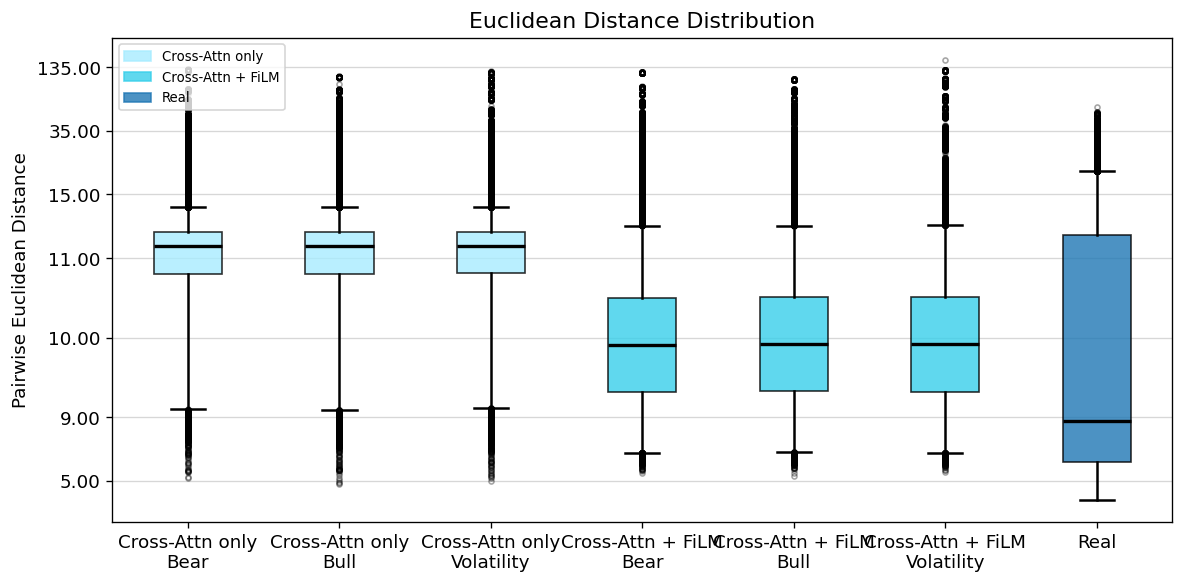

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

center_value = 10
euc_series = [euc_gen[(model, cond_key)] for model, cond_key in gen_keys] + [euc_real]
shifted_euc_series = [vals - center_value for vals in euc_series]

tick_labels = [box_tick_label(model, cond_key) for model, cond_key in gen_keys] + ['Real']

bp = ax.boxplot(
    shifted_euc_series,
    tick_labels=tick_labels,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)

for i, (model, _cond_key) in enumerate(gen_keys):
    color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
    bp['boxes'][i].set_facecolor(color)
    bp['boxes'][i].set_alpha(0.8)

bp['boxes'][-1].set_facecolor(C_REAL)
bp['boxes'][-1].set_alpha(0.8)

ax.set_title('Euclidean Distance Distribution')
ax.set_ylabel('Pairwise Euclidean Distance')
ax.set_yscale('symlog', linthresh=1, base=5)

yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([f'{tick + center_value:.2f}' for tick in yticks])

gen_ca_handle = mpatches.Patch(color=C_GEN_CA, alpha=0.8, label=MODEL_LABELS['ca'])
gen_cafilm_handle = mpatches.Patch(color=C_GEN_CAFILM, alpha=0.8, label=MODEL_LABELS['ca-film'])
real_handle = mpatches.Patch(color=C_REAL, alpha=0.8, label='Real')
ax.legend(handles=[gen_ca_handle, gen_cafilm_handle, real_handle], loc='upper left', fontsize=8)

ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('../../figures/diversity_euclidean.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
"""
2.2 - DTW diversity metrics.
"""
DTW_MAX_PAIRS = 10000
print(f'Computing DTW distances with sampled pairs (max_pairs={DTW_MAX_PAIRS})...')

dtw_gen = {}
for model, cond_key in gen_keys:
    arr = gen_data[model][cond_key]['samples']
    idx_i, idx_j = sample_pair_indices(arr.shape[0], DTW_MAX_PAIRS, rng)
    dtw_gen[(model, cond_key)] = dtw_on_pairs(arr, idx_i, idx_j)

idx_i_real_dtw, idx_j_real_dtw = sample_pair_indices(real_np.shape[0], DTW_MAX_PAIRS, rng)
dtw_real = dtw_on_pairs(real_np, idx_i_real_dtw, idx_j_real_dtw)


Computing DTW distances with sampled pairs (max_pairs=10000)...


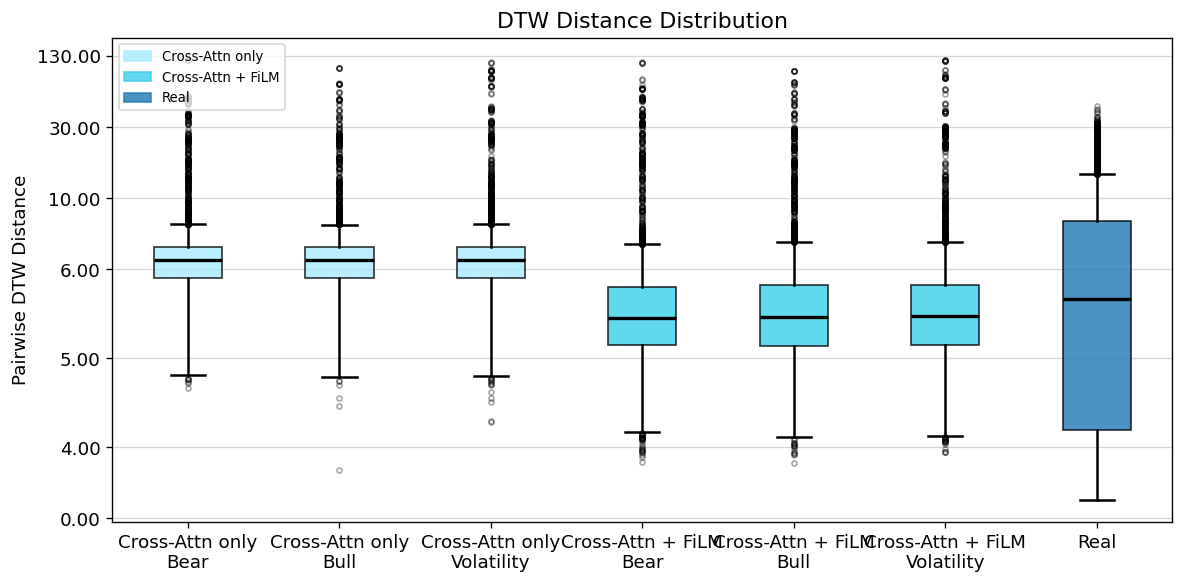

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

center_value = 5
dtw_series = [dtw_gen[(model, cond_key)] for model, cond_key in gen_keys] + [dtw_real]
shifted_dtw_series = [vals - center_value for vals in dtw_series]

tick_labels = [box_tick_label(model, cond_key) for model, cond_key in gen_keys] + ['Real']

bp = ax.boxplot(
    shifted_dtw_series,
    tick_labels=tick_labels,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)

for i, (model, _cond_key) in enumerate(gen_keys):
    color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
    bp['boxes'][i].set_facecolor(color)
    bp['boxes'][i].set_alpha(0.8)

bp['boxes'][-1].set_facecolor(C_REAL)
bp['boxes'][-1].set_alpha(0.8)

ax.set_title('DTW Distance Distribution')
ax.set_ylabel('Pairwise DTW Distance')
ax.set_yscale('symlog', linthresh=1, base=5)

yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([f'{tick + center_value:.2f}' for tick in yticks])

gen_ca_handle = mpatches.Patch(color=C_GEN_CA, alpha=0.8, label=MODEL_LABELS['ca'])
gen_cafilm_handle = mpatches.Patch(color=C_GEN_CAFILM, alpha=0.8, label=MODEL_LABELS['ca-film'])
real_handle = mpatches.Patch(color=C_REAL, alpha=0.8, label='Real')
ax.legend(handles=[gen_ca_handle, gen_cafilm_handle, real_handle], loc='upper left', fontsize=8)

ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('../../figures/diversity_dtw.png', dpi=150, bbox_inches='tight')
plt.show()


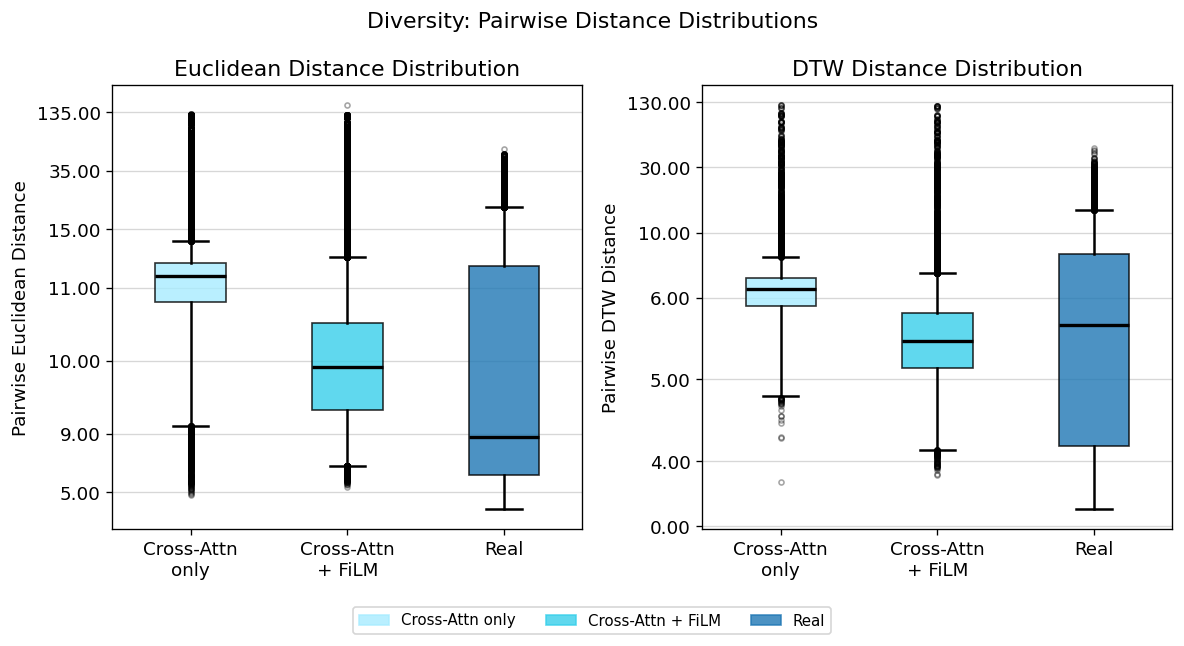

In [13]:
# Combined figure: Euclidean (left) + DTW (right), one box per model

fig, (ax_euc, ax_dtw) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Diversity: Pairwise Distance Distributions')

euc_ca = np.concatenate([euc_gen[('ca', ck)] for ck in cond_keys])
euc_cafilm = np.concatenate([euc_gen[('ca-film', ck)] for ck in cond_keys])
dtw_ca = np.concatenate([dtw_gen[('ca', ck)] for ck in cond_keys])
dtw_cafilm = np.concatenate([dtw_gen[('ca-film', ck)] for ck in cond_keys])

BOX_COLORS = [C_GEN_CA, C_GEN_CAFILM, C_REAL]
BOX_LABELS = ['Cross-Attn\nonly', 'Cross-Attn\n+ FiLM', 'Real']


def _style_bp(bp, colors):
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
        box.set_alpha(0.8)


euc_center = 10
euc_shifted = [v - euc_center for v in [euc_ca, euc_cafilm, euc_real]]

bp_euc = ax_euc.boxplot(
    euc_shifted,
    tick_labels=BOX_LABELS,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)
_style_bp(bp_euc, BOX_COLORS)

ax_euc.set_title('Euclidean Distance Distribution')
ax_euc.set_ylabel('Pairwise Euclidean Distance')
ax_euc.set_yscale('symlog', linthresh=1, base=5)
yticks = ax_euc.get_yticks()
ax_euc.set_yticks(yticks)
ax_euc.set_yticklabels([f'{t + euc_center:.2f}' for t in yticks])
ax_euc.grid(axis='y', alpha=0.5)

dtw_center = 5
dtw_shifted = [v - dtw_center for v in [dtw_ca, dtw_cafilm, dtw_real]]

bp_dtw = ax_dtw.boxplot(
    dtw_shifted,
    tick_labels=BOX_LABELS,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)
_style_bp(bp_dtw, BOX_COLORS)

ax_dtw.set_title('DTW Distance Distribution')
ax_dtw.set_ylabel('Pairwise DTW Distance')
ax_dtw.set_yscale('symlog', linthresh=1, base=5)
yticks = ax_dtw.get_yticks()
ax_dtw.set_yticks(yticks)
ax_dtw.set_yticklabels([f'{t + dtw_center:.2f}' for t in yticks])
ax_dtw.grid(axis='y', alpha=0.5)

handles = [
    mpatches.Patch(color=C_GEN_CA, alpha=0.8, label=MODEL_LABELS['ca']),
    mpatches.Patch(color=C_GEN_CAFILM, alpha=0.8, label=MODEL_LABELS['ca-film']),
    mpatches.Patch(color=C_REAL, alpha=0.8, label='Real'),
]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout()
plt.savefig('../../figures/diversity_combined.png', dpi=150, bbox_inches='tight')
plt.show()


## Micro conditioning

50-file grid from `data/generated_gen1_older/` (April models, `i5v20` / `i8v35`).
Load + denorm logic from commit `e89c02c`; labels match above.


In [14]:
"""
Load micro-conditioning grid (50 JSONs per model).
"""
from config.preprocess_config import T

MICRO_MODEL_DIRS = {
    'ca': Path('../../data/generated_gen1_older/ca'),
    'ca-film': Path('../../data/generated_gen1_older/ca-film'),
}
MODEL_COLORS = {'ca': C_GEN_CA, 'ca-film': C_GEN_CAFILM}

MICRO_ALL_FILES = sorted(f.name for f in next(iter(MICRO_MODEL_DIRS.values())).glob('*.json'))
for model, base_dir in MICRO_MODEL_DIRS.items():
    model_files = sorted(f.name for f in base_dir.glob('*.json'))
    if model_files != MICRO_ALL_FILES:
        raise FileNotFoundError(
            f'{model}: expected {len(MICRO_ALL_FILES)} files matching ca grid, got {len(model_files)}'
        )

micro_gen_data = {}
for model, base_dir in MICRO_MODEL_DIRS.items():
    micro_gen_data[model] = {}
    for filename in MICRO_ALL_FILES:
        with open(base_dir / filename) as f:
            payload = json.load(f)
        samples = np.array(payload['samples'], dtype=np.float64)
        t_tgt = payload['conditions']['trend']
        r_tgt = payload['conditions']['realized_vol']
        mean_w = t_tgt / (100.0 * T)
        var_w = (r_tgt / (100.0 ** 2) - T * mean_w ** 2) / (T - 1)
        std_w = np.sqrt(np.maximum(var_w, 1e-12))
        samples = samples * std_w + mean_w

        micro_gen_data[model][filename] = {
            'n_samples': samples.shape[0],
            'trend_target': t_tgt,
            'trend_achieved': np.sum(samples * 100, axis=1),
            'rv_target': r_tgt,
            'rv_achieved': np.sum((samples * 100) ** 2, axis=1),
        }

print(f'Micro data loaded: {len(MICRO_ALL_FILES)} conditions x {len(MICRO_MODEL_DIRS)} models')


Micro data loaded: 50 conditions x 2 models


In [15]:
"""
Trend adherence.
"""
print(f"{'=' * 25} Trend Adherence {'=' * 26}\n")
trend_pts = {}
for model in MICRO_MODEL_DIRS:
    targets, mean_achieved = adherence_table('trend', model, micro_gen_data, MICRO_ALL_FILES)
    trend_pts[model] = (targets, mean_achieved)
    print()


========================= Trend Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r30i5v20.json         -10.00    -10.0515      3.6761      0.0515
t-10r30i8v35.json         -10.00    -10.0797      4.7365      0.0797
t-10r40i5v20.json         -10.00     -9.9807      3.1188      0.0193
t-10r40i8v35.json         -10.00    -10.0393      2.7152      0.0393
t-10r50i5v20.json         -10.00    -10.0978      4.1511      0.0978
t-10r50i8v35.json         -10.00    -10.0809      6.4886      0.0809
t-10r60i5v20.json         -10.00    -10.0029      4.2731      0.0029
t-10r60i8v35.json         -10.00    -10.1478      4.3080      0.1478
t-10r70i5v20.json         -10.00    -10.2175      5.4419      0.2175
t-10r70i8v35.json         -10.00    -10.1579      4.6595      0.1579
t-5r30i5v20.json           -5.00     -5.0910      4.0248      0.0910
t-5r30i8v35.json           -5.00 

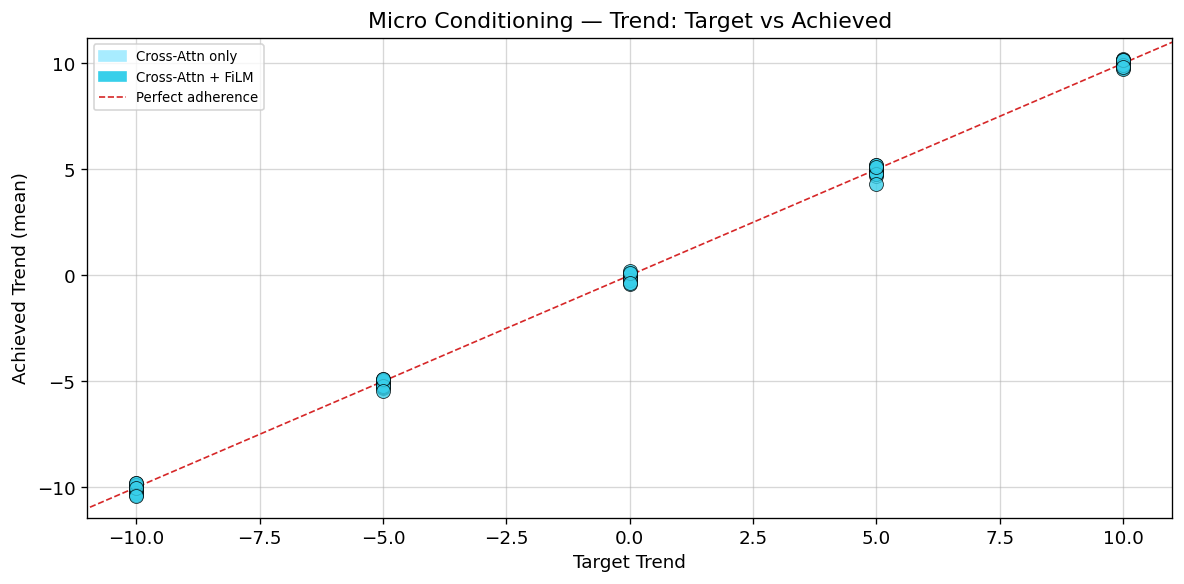

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

for model, (targets, mean_achieved) in trend_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])]
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Trend')
ax.set_ylim(ylim)
ax.set_ylabel('Achieved Trend (mean)')
ax.set_title('Micro Conditioning — Trend: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MICRO_MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('../../figures/conditioning_trend.png')
plt.show()


In [17]:
"""
Realized volatility adherence.
"""
print(f"{'=' * 25} Realized Vol Adherence {'=' * 26}\n")
rv_pts = {}
for model in MICRO_MODEL_DIRS:
    targets, mean_achieved = adherence_table('rv', model, micro_gen_data, MICRO_ALL_FILES)
    rv_pts[model] = (targets, mean_achieved)
    print()


========================= Realized Vol Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r30i5v20.json          30.00     37.7024    128.3515      7.7024
t-10r30i8v35.json          30.00     37.1452    171.8800      7.1452
t-10r40i5v20.json          40.00     47.5835    114.3869      7.5835
t-10r40i8v35.json          40.00     46.4671     83.7810      6.4671
t-10r50i5v20.json          50.00     62.7278    212.2121     12.7278
t-10r50i8v35.json          50.00     68.1951    325.9896     18.1951
t-10r60i5v20.json          60.00     72.5889    211.4143     12.5889
t-10r60i8v35.json          60.00     81.0978    493.7512     21.0978
t-10r70i5v20.json          70.00     81.4412    133.4452     11.4412
t-10r70i8v35.json          70.00     85.3085    190.2612     15.3085
t-5r30i5v20.json           30.00     40.1160    136.1723     10.1160
t-5r30i8v35.json          

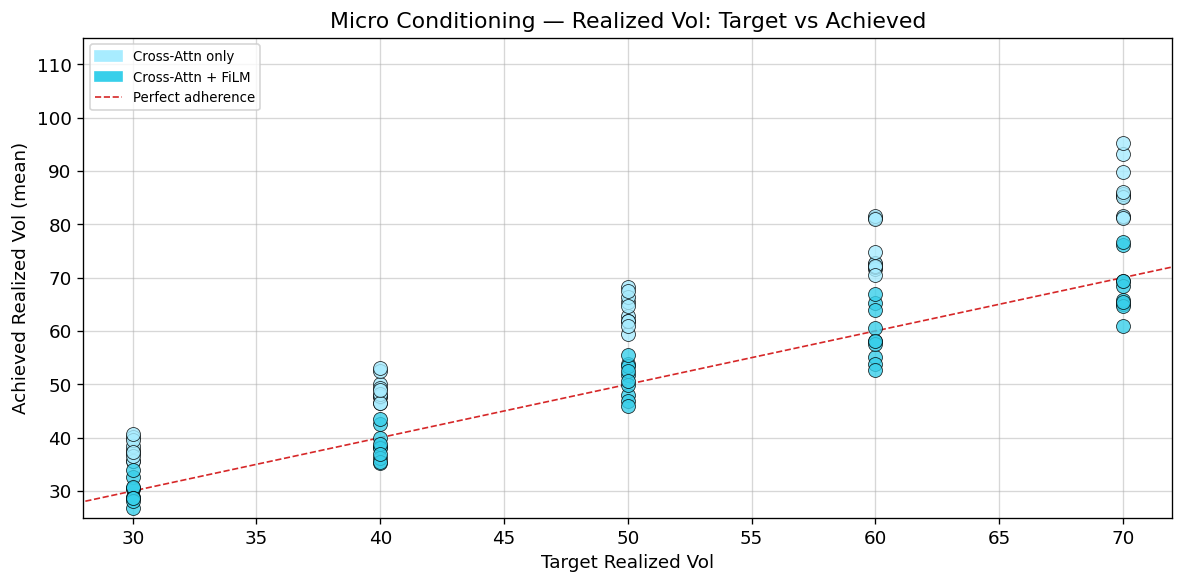

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

for model, (targets, mean_achieved) in rv_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])]
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Realized Vol')
ax.set_ylim(25, 115)
ax.set_ylabel('Achieved Realized Vol (mean)')
ax.set_title('Micro Conditioning — Realized Vol: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MICRO_MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('../../figures/conditioning_rv.png')
plt.show()


## Macro conditioning

9 micro cells × 2 macro regimes from `data/generated_gen1_older/` (`i5v20` normal, `i8v35` stress).
Load + denorm logic from commit `6248a83`; labels match above.


In [21]:
"""
Macro plot config + load (18 JSONs per model).
"""

MACRO_MODEL_DIRS = MICRO_MODEL_DIRS
MACRO_TRENDS = [-10, 0, 10]
MACRO_RVS = [30, 50, 70]
MACRO_REGIMES = {'normal': (5, 20), 'stress': (8, 35)}

MACRO_GROUPS = [
    ('ca', 'normal', 'tab:blue', f"{MODEL_LABELS['ca']} · normal (IR 5, VIX 20)"),
    ('ca', 'stress', 'tab:green', f"{MODEL_LABELS['ca']} · stress (IR 8, VIX 35)"),
    ('ca-film', 'normal', 'tab:red', f"{MODEL_LABELS['ca-film']} · normal (IR 5, VIX 20)"),
    ('ca-film', 'stress', 'tab:orange', f"{MODEL_LABELS['ca-film']} · stress (IR 8, VIX 35)"),
]

TREND_LABELS = {-10: 'Low (−10%)', 0: 'Base (0%)', 10: 'High (+10%)'}
RV_LABELS = {30: 'Low (30)', 50: 'Base (50)', 70: 'High (70)'}

macro_gen_data = {}
for model, base_dir in MACRO_MODEL_DIRS.items():
    for macro_key, (ir, vix) in MACRO_REGIMES.items():
        group_key = (model, macro_key)
        macro_gen_data[group_key] = {}
        for trend in MACRO_TRENDS:
            for rv in MACRO_RVS:
                filename = f"t{int(trend)}r{int(rv)}i{int(ir)}v{int(vix)}.json"
                with open(base_dir / filename) as f:
                    payload = json.load(f)
                samples = np.array(payload['samples'], dtype=np.float64)
                mean_w = payload['conditions']['trend'] / (100.0 * T)
                var_w = (payload['conditions']['realized_vol'] / (100.0 ** 2) - T * mean_w ** 2) / (T - 1)
                std_w = np.sqrt(np.maximum(var_w, 1e-12))
                samples_pct = (samples * std_w + mean_w) * 100.0
                macro_gen_data[group_key][(trend, rv)] = samples_pct

for (model, macro_key), cell_dict in macro_gen_data.items():
    arr = next(iter(cell_dict.values()))
    print(
        f"[{MODEL_LABELS[model]} | {macro_key}]: "
        f"{len(cell_dict)} cells, each {arr.shape[0]} sequences × {arr.shape[1]} steps"
    )


[Cross-Attn only | normal]: 9 cells, each 5000 sequences × 64 steps
[Cross-Attn only | stress]: 9 cells, each 5000 sequences × 64 steps
[Cross-Attn + FiLM | normal]: 9 cells, each 5000 sequences × 64 steps
[Cross-Attn + FiLM | stress]: 9 cells, each 5000 sequences × 64 steps


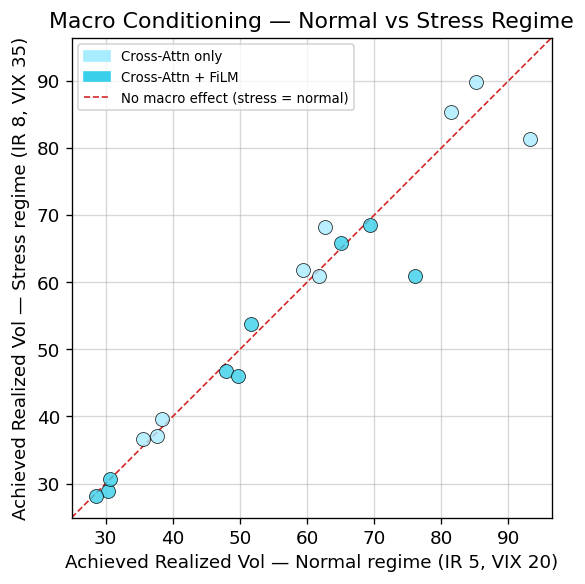

In [27]:
"""
Macro adherence — Normal vs Stress regime scatter.
Each dot = one (trend, RV) micro cell; y=x line = 'no macro effect'.
"""
macro_pts = {model: {'normal': [], 'stress': []} for model in MACRO_MODEL_DIRS}
for model in MACRO_MODEL_DIRS:
    for trend in MACRO_TRENDS:
        for rv in MACRO_RVS:
            for regime in ['normal', 'stress']:
                arr = macro_gen_data[(model, regime)][(trend, rv)]
                macro_pts[model][regime].append((arr ** 2).sum(axis=1).mean())

fig, ax = plt.subplots(figsize=(10, 5))

for model in MACRO_MODEL_DIRS:
    ax.scatter(
        macro_pts[model]['normal'], macro_pts[model]['stress'],
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

all_vals = [v for model in MACRO_MODEL_DIRS for regime in ['normal', 'stress'] for v in macro_pts[model][regime]]
lo, hi = min(all_vals), max(all_vals)
pad = 0.05 * (hi - lo)
lims = [lo - pad, hi + pad]
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Achieved Realized Vol — Normal regime (IR 5, VIX 20)')
ax.set_ylabel('Achieved Realized Vol — Stress regime (IR 8, VIX 35)')
ax.set_title('Macro Conditioning — Normal vs Stress Regime')
ax.grid(alpha=0.5)

legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MACRO_MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='No macro effect (stress = normal)')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('../../figures/macro_normal_vs_stress.png')
plt.show()
